In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('filtered_ids.txt')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=None)


In [3]:
SPECTRA = SPECTRA.subtype_filter(subtype='QSO', exclude=True)

SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
print(SPECTRA.n_spectra)


99831


In [5]:
SPECTRA = FIT.label_emission_lines(SPECTRA)
SPECTRA = FIT.significant_emission_filter(SPECTRA)
print(SPECTRA.n_spectra)

16633


In [ ]:
SPECTRA = FIT.line_ratios(SPECTRA)

,TARGETID,RA,DEC,SPECTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,LOGM,LOGSFR,z_pipe,z,OII,OIII,Halpha,NII,Hbeta,OIII_Hbeta_ratio,NII_Halpha_ratio
0,39627739380059797,177.158055,-1.894803,GALAXY,11.876244,27.585695,51.631172,60.959381,42.316128,10.211300,0.980484,0.191538,0.191538,True,True,True,True,True,0.461049,0.429208
1,39627739384253125,177.367221,-1.890628,GALAXY,23.732853,42.791225,65.784187,69.734558,48.058872,9.603887,0.054528,0.082792,0.082792,True,True,True,True,True,0.204611,0.311962
2,39627739388446113,177.554279,-1.971866,GALAXY,151.215744,293.643341,476.334869,496.636810,362.531738,10.489296,0.985447,0.083630,0.083630,False,True,True,True,True,0.838553,0.478740
3,39627739388449631,177.694199,-1.960243,GALAXY,292.573456,476.650604,683.231384,405.080902,238.632812,9.270416,-0.137936,0.019300,0.019300,False,True,True,True,True,0.470630,0.316409
4,39627739388450085,177.708902,-1.988507,GALAXY,23.671574,38.927528,55.839462,48.287712,42.088276,10.169886,0.802034,0.174826,0.174826,True,True,True,True,True,0.885116,0.413126
5,39627739392639670,177.772018,-1.978700,GALAXY,25.959066,38.303490,52.766968,37.510757,23.016556,9.521446,-0.091108,0.092415,0.092415,False,True,True,True,True,1.341604,0.141329
6,39627739392642816,177.899146,-1.878202,GALAXY,16.970976,25.512915,33.270302,24.918797,18.424887,9.211570,-0.308620,0.080528,0.080528,True,True,True,True,True,2.198091,0.169928
7,39627739392643871,177.943066,-1.937681,GALAXY,26.395004,40.629482,55.444244,37.319523,29.269014,9.315753,0.107977,0.083135,0.083135,False,True,True,True,True,0.923885,0.200457
8,39627739392644168,177.958389,-1.975597,GALAXY,21.233454,32.118713,44.819260,34.608036,20.868193,9.398454,-0.045431,0.091896,0.091896,False,True,True,True,True,0.843970,0.248195
9,39627739396833489,178.007400,-1.904926,GALAXY,16.407036,24.058228,30.796312,22.958490,18.688957,8.915884,-0.494116,0.060347,0.060347,True,True,True,True,True,3.247002,0.138456


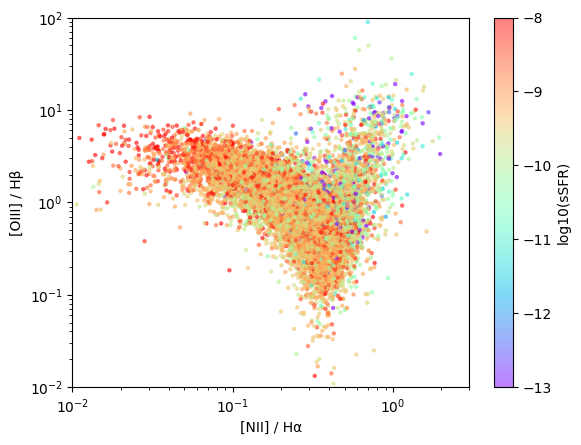

In [19]:



# Use a scatter plot to color points by star formation rate
# Taking the log of SFR for better color mapping
ssfr = SPECTRA.df['LOGSFR'] - SPECTRA.df['LOGM']
ssfr = np.clip(ssfr, -13, -8)  # Clip values for better color contrast

plt.scatter(SPECTRA.df['NII_Halpha_ratio'], SPECTRA.df['OIII_Hbeta_ratio'], 
            c=ssfr, cmap='rainbow', s=5, alpha=0.5)

# Add a colorbar and label it
cbar = plt.colorbar()
cbar.set_label('log10(sSFR)')

plt.xlabel('[NII] / Hα')
plt.ylabel('[OIII] / Hβ')
plt.xscale('log')
plt.yscale('log')

# Set plot limits to focus on the main cluster of points
plt.xlim(1e-2, 3e0)
plt.ylim(1e-2, 1e2)
plt.savefig('./figures/Dec10/BPT_diagram_ssfr_colored.png', dpi=300)
plt.show()